# Notebook 1 — Evaluation of LLMs: established benchmarks + reinforcement-learning-based metrics

**CV claim this notebook backs up**
> *Systematic evaluation of LLMs using established benchmarks and reinforcement-learning-based metrics.*

**What it does (all numbers are computed by running the models — nothing is simulated or hard-coded)**

| Layer | What is measured | Benchmark / tool |
|---|---|---|
| Established benchmarks | Grade-school math reasoning (exact match) | **GSM8K** (test) |
| | Science multiple-choice QA (accuracy) | **ARC-Challenge** (test) |
| | Abstractive summarisation | **CNN/DailyMail 3.0.0** (test) |
| Classical metrics (report ch. 1) | BLEU, ROUGE-1/2/L, METEOR, BERTScore, perplexity of the generated text | sacrebleu, rouge-score, nltk, bert-score |
| RL-based metrics (report ch. 2) | (a) **verifiable rule-based reward** (GSM8K/ARC), (b) **learned reward-model score** (RLHF-style RM), (c) **Monte-Carlo expected return** J(π) with k sampled rollouts + bootstrap CI, (d) **self-critical advantage** A = r(sample) − r(greedy) (the SCST/REINFORCE-with-baseline signal), (e) pass@k / maj@k | own code |
| Hybrid (report ch. 3) | α·classical + β·reward, pooled min-max normalisation, **α-sensitivity / ranking-stability analysis** | own code |
| Reproducibility | fixed seeds, config + library versions + model commit hashes in `run_manifest.json`, resumable per-model caches | — |

**Models compared (same prompts, same decoding, same metrics):** Qwen2.5-1.5B-Instruct, Qwen2.5-3B-Instruct, SmolLM2-1.7B-Instruct (edit `CFG["llms"]` to add more, e.g. a gated Llama after `huggingface-cli login`).

**Important honesty notes**
* RL here means *RL-based **evaluation*** (rewards, returns, advantages estimated at evaluation time with frozen weights) — no policy is trained.
* Sample sizes are small by default (GSM8K 100, ARC 200, CNN/DM 50) so it fits a laptop; bootstrap CIs are reported so you can say how wide the uncertainty is. Numbers are **not** comparable with public leaderboards (different prompt, subset, decoding).
* Runs standalone: needs only internet (to download models/datasets once) and the CUDA GPU.


In [18]:
# ============================================================================
# 0. ENVIRONMENT  (run the installs once, in a terminal, BEFORE opening the notebook)
# ----------------------------------------------------------------------------
# RTX 50-series laptops (Blackwell, compute capability sm_120) need a PyTorch
# build compiled against CUDA 12.8 or newer:
#     pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128
#     pip install -r requirements.txt
# ============================================================================
import os, sys, json, time, random, platform, re, math, itertools, warnings, gc
from importlib import metadata
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()

# ---- GPU sanity check (fails loudly instead of silently running on CPU) ----
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available. Install the cu128 PyTorch build (see the top of this cell) "
                       "and make sure the NVIDIA driver is up to date.")
DEVICE = "cuda"
_cap = torch.cuda.get_device_capability(0)
_arch = f"sm_{_cap[0]}{_cap[1]}"
if _arch not in torch.cuda.get_arch_list():
    raise RuntimeError(f"This PyTorch build ({torch.__version__}) has no kernels for {_arch} "
                       f"(GPU: {torch.cuda.get_device_name(0)}). Install the cu128 build: "
                       "pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128")
DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
print(f"GPU     : {torch.cuda.get_device_name(0)}  ({_arch}, "
      f"{torch.cuda.get_device_properties(0).total_memory/2**30:.1f} GiB)")
print(f"PyTorch : {torch.__version__} | CUDA {torch.version.cuda} | dtype for generation: {DTYPE}")


GPU     : NVIDIA GeForce RTX 5070 Laptop GPU  (sm_120, 8.0 GiB)
PyTorch : 2.11.0+cu128 | CUDA 12.8 | dtype for generation: torch.bfloat16


In [19]:
# ============================================================================
# Shared utilities: statistics, reproducibility manifest, tables
# ============================================================================
def free_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def bootstrap_ci(x, n_boot=2000, alpha=0.05, seed=SEED):
    """Percentile bootstrap CI of the mean. Returns (mean, lo, hi)."""
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(x), size=(n_boot, len(x)))
    means = x[idx].mean(axis=1)
    return float(x.mean()), float(np.quantile(means, alpha / 2)), float(np.quantile(means, 1 - alpha / 2))

def paired_bootstrap(a, b, n_boot=2000, seed=SEED):
    """Paired bootstrap of mean(a-b) over items. Returns (mean_diff, lo, hi, P(diff<=0))."""
    d = np.asarray(a, float) - np.asarray(b, float)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(d), size=(n_boot, len(d)))
    m = d[idx].mean(axis=1)
    return float(d.mean()), float(np.quantile(m, 0.025)), float(np.quantile(m, 0.975)), float((m <= 0).mean())

def ci_str(t, nd=3):
    m, lo, hi = t
    return f"{m:.{nd}f} [{lo:.{nd}f}, {hi:.{nd}f}]"

def minmax(x, lo=None, hi=None):
    x = np.asarray(x, dtype=float)
    lo = x.min() if lo is None else lo
    hi = x.max() if hi is None else hi
    return (x - lo) / (hi - lo + 1e-12)

def df_to_md(df, nd=3):
    cols = list(df.columns)
    def f(v):
        return f"{v:.{nd}f}" if isinstance(v, (float, np.floating)) else str(v)
    lines = ["| " + " | ".join(map(str, cols)) + " |", "|" + "|".join(["---"] * len(cols)) + "|"]
    for _, r in df.iterrows():
        lines.append("| " + " | ".join(f(r[c]) for c in cols) + " |")
    return "\n".join(lines)

def write_manifest(path, config, extra=None):
    """Everything needed to reproduce / audit a run."""
    pk = ["torch", "transformers", "datasets", "accelerate", "sacrebleu", "rouge-score", "nltk",
          "bert-score", "pycocoevalcap", "scipy", "numpy", "pandas", "pillow"]
    ver = {}
    for p in pk:
        try: ver[p] = metadata.version(p)
        except Exception: ver[p] = None
    man = dict(
        timestamp=time.strftime("%Y-%m-%d %H:%M:%S"),
        python=sys.version.split()[0], platform=platform.platform(),
        gpu=torch.cuda.get_device_name(0), cuda=torch.version.cuda, torch=torch.__version__,
        versions=ver, seed=SEED, config=config, **(extra or {}),
    )
    with open(path, "w") as fh:
        json.dump(man, fh, indent=2, default=str)
    return man


In [20]:
# ---------------------------------------------------------------
#               Large models' sizes
# ---------------------------------------------------------------

# OUT_DIR = "outputs_llm"; os.makedirs(OUT_DIR, exist_ok=True)

# CFG = dict(
#     llms = {
#         "Qwen2.5-1.5B-Instruct": "Qwen/Qwen2.5-1.5B-Instruct",
#         "Qwen2.5-3B-Instruct":   "Qwen/Qwen2.5-3B-Instruct",
#         "SmolLM2-1.7B-Instruct": "HuggingFaceTB/SmolLM2-1.7B-Instruct",
#     },
#     n_gsm8k=100, n_arc=200, n_cnn=50,          # increase for tighter CIs (runtime grows linearly)
#     k_samples=4, temperature=0.7, top_p=0.95,  # policy rollouts for Monte-Carlo return / advantage
#     gsm8k_max_new=320, sum_max_new=160, max_article_tokens=700,
#     gen_batch_gsm=8, gen_batch_sum=4, arc_batch=8,   # halved automatically on CUDA OOM
#     reward_model="OpenAssistant/reward-model-deberta-v3-large-v2",
#     alpha=0.4, beta=0.6,                       # hybrid weights (ch. 3); sensitivity is reported
#     resume=True,                               # reuse cached generations in OUT_DIR
# )
# print(json.dumps({k: v for k, v in CFG.items() if k != "llms"}, indent=2)); print(list(CFG["llms"]))


OUT_DIR = "outputs_llm"
os.makedirs(OUT_DIR, exist_ok=True)

CFG = dict(
    llms={  # all three < 1 GB of weights in bf16
        "Qwen2.5-1.5B-Instruct": "Qwen/Qwen2.5-1.5B-Instruct",
        "SmolLM2-135M-Instruct": "HuggingFaceTB/SmolLM2-135M-Instruct",  # ~0.27 GB
        "SmolLM2-360M-Instruct": "HuggingFaceTB/SmolLM2-360M-Instruct",  # ~0.72 GB
        "Qwen2.5-0.5B-Instruct": "Qwen/Qwen2.5-0.5B-Instruct",  # ~0.99 GB
    },
    n_gsm8k=100,
    n_arc=200,
    n_cnn=50,  # increase for tighter CIs (runtime grows linearly)
    k_samples=4,
    temperature=0.7,
    top_p=0.95,  # policy rollouts for Monte-Carlo return / advantage
    gsm8k_max_new=320,
    sum_max_new=160,
    max_article_tokens=700,
    gen_batch_gsm=16,
    gen_batch_sum=8,
    arc_batch=16,  # bigger batches are fine with tiny models; halved on OOM
    reward_model="OpenAssistant/reward-model-deberta-v3-base",  # ~0.74 GB in fp32 (large-v2 is ~1.7 GB)
    alpha=0.4,
    beta=0.6,  # hybrid weights (ch. 3); sensitivity is reported
    resume=True,  # reuse cached generations in OUT_DIR
)
print(json.dumps({k: v for k, v in CFG.items() if k != "llms"}, indent=2))
print(list(CFG["llms"]))

{
  "n_gsm8k": 100,
  "n_arc": 200,
  "n_cnn": 50,
  "k_samples": 4,
  "temperature": 0.7,
  "top_p": 0.95,
  "gsm8k_max_new": 320,
  "sum_max_new": 160,
  "max_article_tokens": 700,
  "gen_batch_gsm": 16,
  "gen_batch_sum": 8,
  "arc_batch": 16,
  "reward_model": "OpenAssistant/reward-model-deberta-v3-base",
  "alpha": 0.4,
  "beta": 0.6,
  "resume": true
}
['Qwen2.5-1.5B-Instruct', 'SmolLM2-135M-Instruct', 'SmolLM2-360M-Instruct', 'Qwen2.5-0.5B-Instruct']


In [21]:
# ============================================================================
# 1. Established benchmarks (parquet datasets -> no remote code execution)
# ============================================================================
from datasets import load_dataset
gsm = load_dataset("openai/gsm8k", "main", split=f"test[:{CFG['n_gsm8k']}]")
arc = load_dataset("allenai/ai2_arc", "ARC-Challenge", split=f"test[:{CFG['n_arc']}]")
cnn = load_dataset("abisee/cnn_dailymail", "3.0.0", split=f"test[:{CFG['n_cnn']}]")
print(f"GSM8K: {len(gsm)} | ARC-Challenge: {len(arc)} | CNN/DailyMail: {len(cnn)}")

GSM8K: 100 | ARC-Challenge: 200 | CNN/DailyMail: 50


In [22]:
# ============================================================================
# 2. Prompts, answer extraction, generation helpers
# ============================================================================
from collections import Counter
from transformers import AutoTokenizer, AutoModelForCausalLM

def load_causal_lm(model_id):
    tok = AutoTokenizer.from_pretrained(model_id)
    tok.padding_side = "left"
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    try:
        model = AutoModelForCausalLM.from_pretrained(model_id, dtype=DTYPE)
    except TypeError:                       # older transformers
        model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=DTYPE)
    return tok, model.to(DEVICE).eval()

def chat_prompt(tok, user):
    return tok.apply_chat_template([{"role": "user", "content": user}], tokenize=False, add_generation_prompt=True)

# ---- GSM8K ----
def gsm_prompt(tok, q):
    return chat_prompt(tok, "Solve the following math problem step by step. Finish with a final line of the form "
                            "'The answer is: <number>'.\n\nProblem: " + q)

_NUM = r"-?\d[\d,]*\.?\d*"
def to_float(s):
    try: return float(s.replace(",", "").rstrip("."))
    except Exception: return None

def extract_answer(text):
    """-> (predicted float or None, followed_format: bool)."""
    m = re.findall(r"answer is:?\s*[\$\\\(\s]*(" + _NUM + ")", text, flags=re.I)
    if m: return to_float(m[-1]), True
    nums = re.findall(_NUM, text)
    return (to_float(nums[-1]) if nums else None), False

def is_correct(pred, gold):
    return pred is not None and gold is not None and abs(pred - gold) < 1e-4

def pass_at_k(n, c, k):
    """Unbiased pass@k estimator (Chen et al., 2021)."""
    if n - c < k: return 1.0
    return 1.0 - math.comb(n - c, k) / math.comb(n, k)

# ---- ARC ----
def arc_prompt(tok, q, choices):
    letters = "ABCDE"[:len(choices)]
    body = "\n".join(f"{l}. {c}" for l, c in zip(letters, choices))
    return chat_prompt(tok, "Answer the following multiple-choice question. Reply with only the letter of the "
                            f"correct option.\n\nQuestion: {q}\n{body}")

@torch.no_grad()
def arc_probs(model, tok, prompts, n_choices, bs):
    """Exact next-token distribution over the option letters -> the policy's action probabilities."""
    ids = [tok.encode(l, add_special_tokens=False)[-1] for l in "ABCDE"]
    out = []
    for i in tqdm(range(0, len(prompts), bs), desc="ARC", leave=False):
        enc = tok(prompts[i:i + bs], return_tensors="pt", padding=True, add_special_tokens=False).to(DEVICE)
        try: logits = model(**enc, logits_to_keep=1).logits[:, -1, :]
        except TypeError: logits = model(**enc).logits[:, -1, :]
        lg = logits[:, ids].float()
        for j in range(lg.shape[0]):
            nc = n_choices[i + j]
            p = torch.softmax(lg[j, :nc], -1).cpu().numpy()
            out.append(np.pad(p, (0, 5 - nc)).tolist())
    return out

# ---- generation with automatic OOM back-off ----
def _gen_chunk(model, tok, batch, kw, n, sample):
    oom = False
    try:
        enc = tok(batch, return_tensors="pt", padding=True, add_special_tokens=False).to(DEVICE)
        with torch.no_grad():
            ids = model.generate(**enc, **kw)
        texts = tok.batch_decode(ids[:, enc["input_ids"].shape[1]:], skip_special_tokens=True)
        return [texts[j * n:(j + 1) * n] for j in range(len(batch))] if sample else texts
    except torch.cuda.OutOfMemoryError:
        oom = True
    free_gpu()
    if len(batch) == 1: raise RuntimeError("CUDA OOM even with batch size 1")
    h = len(batch) // 2
    print(f"  OOM -> splitting batch {len(batch)} -> {h}+{len(batch)-h}")
    return _gen_chunk(model, tok, batch[:h], kw, n, sample) + _gen_chunk(model, tok, batch[h:], kw, n, sample)

def generate(model, tok, prompts, max_new, bs, sample=False, n=1, desc=""):
    kw = dict(max_new_tokens=max_new, pad_token_id=tok.pad_token_id)
    if sample:
        kw.update(do_sample=True, temperature=CFG["temperature"], top_p=CFG["top_p"], top_k=0, num_return_sequences=n)
    else:
        kw.update(do_sample=False, temperature=None, top_p=None, top_k=None)
    out = []
    for i in tqdm(range(0, len(prompts), bs), desc=desc, leave=False):
        out.extend(_gen_chunk(model, tok, prompts[i:i + bs], kw, n, sample))
    return out

@torch.no_grad()
def response_ppl(model, tok, prompts, responses):
    """Reference-free fluency: perplexity of the response under the model that produced it (report ch. 1)."""
    vals = []
    for p, r in zip(prompts, responses):
        pi = tok(p, add_special_tokens=False, return_tensors="pt").input_ids
        ri = tok(r, add_special_tokens=False, return_tensors="pt").input_ids
        if ri.shape[1] == 0: vals.append(np.nan); continue
        ids = torch.cat([pi, ri], 1).to(DEVICE)
        labels = ids.clone(); labels[:, :pi.shape[1]] = -100
        vals.append(math.exp(model(input_ids=ids, labels=labels).loss.item()))
    return vals

def truncate_article(tok, text, max_tokens):
    ids = tok(text, add_special_tokens=False).input_ids
    return text if len(ids) <= max_tokens else tok.decode(ids[:max_tokens])

SUM_INSTR = "Summarize the following news article in three sentences.\n\n"

In [23]:
# ============================================================================
# 3. STAGE 1 - roll out every LLM (greedy baseline + k stochastic samples) on all benchmarks
#    One model on the GPU at a time; results cached to disk so a crash never costs the whole run.
# ============================================================================
def run_generation(name, model_id):
    cache = f"{OUT_DIR}/gen_{name}.json"
    if CFG["resume"] and os.path.exists(cache):
        print(f"[{name}] loading cached generations"); return json.load(open(cache))
    print(f"\n{'='*78}\n[{name}] {model_id}\n{'='*78}")
    set_seed(); torch.cuda.reset_peak_memory_stats()
    tok, model = load_causal_lm(model_id)
    K = CFG["k_samples"]; res = dict(model_id=model_id)
    res["commit"] = getattr(model.config, "_commit_hash", None)
    res["params_m"] = round(sum(p.numel() for p in model.parameters()) / 1e6, 1)
    t0 = time.time()

    gp = [gsm_prompt(tok, q) for q in gsm["question"]]
    res["gsm_greedy"]  = generate(model, tok, gp, CFG["gsm8k_max_new"], CFG["gen_batch_gsm"], desc="GSM8K greedy")
    res["gsm_samples"] = generate(model, tok, gp, CFG["gsm8k_max_new"], CFG["gen_batch_gsm"], True, K, "GSM8K samples")

    ap = [arc_prompt(tok, q, c["text"]) for q, c in zip(arc["question"], arc["choices"])]
    res["arc_probs"] = arc_probs(model, tok, ap, [len(c["text"]) for c in arc["choices"]], CFG["arc_batch"])

    arts = [truncate_article(tok, a, CFG["max_article_tokens"]) for a in cnn["article"]]
    sp = [chat_prompt(tok, SUM_INSTR + a) for a in arts]
    res["sum_greedy"]  = [s.strip() for s in generate(model, tok, sp, CFG["sum_max_new"], CFG["gen_batch_sum"], desc="CNN/DM greedy")]
    res["sum_samples"] = [[s.strip() for s in ss] for ss in
                          generate(model, tok, sp, CFG["sum_max_new"], CFG["gen_batch_sum"], True, K, "CNN/DM samples")]
    res["sum_ppl"] = response_ppl(model, tok, sp, res["sum_greedy"])

    res["gen_seconds"] = round(time.time() - t0, 1)
    res["peak_vram_gib"] = round(torch.cuda.max_memory_allocated() / 2**30, 2)
    json.dump(res, open(cache, "w"))
    del model, tok; free_gpu()
    print(f"[{name}] done in {res['gen_seconds']}s | peak VRAM {res['peak_vram_gib']} GiB")
    return res

GEN = {name: run_generation(name, mid) for name, mid in CFG["llms"].items()}

[Qwen2.5-1.5B-Instruct] loading cached generations

[SmolLM2-135M-Instruct] HuggingFaceTB/SmolLM2-135M-Instruct


Loading weights: 100%|██████████| 272/272 [00:00<00:00, 1279.41it/s]


[SmolLM2-135M-Instruct] done in 440.1s | peak VRAM 1.14 GiB

[SmolLM2-360M-Instruct] HuggingFaceTB/SmolLM2-360M-Instruct


Loading weights: 100%|██████████| 290/290 [00:00<00:00, 403.92it/s]


[SmolLM2-360M-Instruct] done in 480.2s | peak VRAM 2.14 GiB

[Qwen2.5-0.5B-Instruct] Qwen/Qwen2.5-0.5B-Instruct


Loading weights: 100%|██████████| 290/290 [00:00<00:00, 592.10it/s]


[Qwen2.5-0.5B-Instruct] done in 181.8s | peak VRAM 2.22 GiB


In [24]:
# ============================================================================
# 4. STAGE 2 - CLASSICAL metrics (report ch. 1)
# ============================================================================
import nltk
for _p in ["wordnet", "omw-1.4"]: nltk.download(_p, quiet=True)
import sacrebleu
from rouge_score import rouge_scorer
from nltk.translate.meteor_score import meteor_score
from bert_score import score as bertscore_fn

_rouge = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
_tokz = lambda s: re.findall(r"\w+", s.lower())
refs_sum = list(cnn["highlights"])
gold_gsm = [to_float(a.split("####")[-1].strip()) for a in gsm["answer"]]
arc_gold = [c["label"].index(k) for c, k in zip(arc["choices"], arc["answerKey"])]

SUM = {}     # per-model summarisation per-sample DataFrames
for name, g in GEN.items():
    preds = g["sum_greedy"]
    r = [_rouge.score(ref, p) for ref, p in zip(refs_sum, preds)]
    _, _, F = bertscore_fn(preds, refs_sum, lang="en", rescale_with_baseline=True, device=DEVICE, batch_size=16, verbose=False)
    SUM[name] = pd.DataFrame({
        "rouge1": [x["rouge1"].fmeasure for x in r], "rouge2": [x["rouge2"].fmeasure for x in r],
        "rougeL": [x["rougeL"].fmeasure for x in r],
        "bleu": [sacrebleu.BLEU(effective_order=True).sentence_score(p, [ref]).score / 100 for p, ref in zip(preds, refs_sum)],
        "meteor": [meteor_score([_tokz(ref)], _tokz(p)) for p, ref in zip(preds, refs_sum)],
        "bertscore_f1": F.numpy(), "ppl": g["sum_ppl"],
        "len_words": [len(p.split()) for p in preds],
    })
    SUM[name]["corpus_bleu"] = sacrebleu.corpus_bleu(preds, [refs_sum]).score / 100
    print(f"[{name}] classical metrics done")
free_gpu()

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 493.18it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[Qwen2.5-1.5B-Instruct] classical metrics done


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 532.68it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[SmolLM2-135M-Instruct] classical metrics done


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 602.44it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[SmolLM2-360M-Instruct] classical metrics done


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 568.34it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[Qwen2.5-0.5B-Instruct] classical metrics done


In [25]:
# ============================================================================
# 5. STAGE 3 - RL-BASED metrics (report ch. 2)
#    (a) verifiable rule-based reward  r = 1[correct] + 0.1*1[followed format]      (GSM8K)
#    (b) exact expected reward of the policy over option letters                      (ARC)
#    (c) learned reward-model score  r_phi(prompt, response)  (RLHF-style RM)         (CNN/DM, GSM8K)
#    (d) Monte-Carlo expected return  J(pi) = mean over k rollouts, bootstrap CI
#    (e) self-critical advantage      A = r(sampled) - r(greedy baseline)
# ============================================================================
K = CFG["k_samples"]

# ---- (a),(d),(e-verifiable) GSM8K ------------------------------------------------
GSM = {}
for name, g in GEN.items():
    gr = [extract_answer(t) for t in g["gsm_greedy"]]
    g_corr = np.array([is_correct(p, gd) for (p, _), gd in zip(gr, gold_gsm)], float)
    g_fmt  = np.array([f for _, f in gr], float)
    s_corr, s_fmt, p1, pk, maj = [], [], [], [], []
    for sl, gd in zip(g["gsm_samples"], gold_gsm):
        ex = [extract_answer(t) for t in sl]
        c = [is_correct(p, gd) for p, _ in ex]
        s_corr.append(np.mean(c)); s_fmt.append(np.mean([f for _, f in ex]))
        p1.append(pass_at_k(len(c), sum(c), 1)); pk.append(pass_at_k(len(c), sum(c), len(c)))
        votes = Counter(round(p, 4) for p, _ in ex if p is not None)
        maj.append(float(bool(votes) and is_correct(votes.most_common(1)[0][0], gd)))
    s_corr, s_fmt = np.array(s_corr), np.array(s_fmt)
    GSM[name] = dict(
        greedy_correct=g_corr, greedy_reward=g_corr + 0.1 * g_fmt,
        sample_reward=s_corr + 0.1 * s_fmt, pass1=np.array(p1), passk=np.array(pk), maj=np.array(maj),
        fmt_rate=float(g_fmt.mean()),
    )
    GSM[name]["advantage"] = GSM[name]["sample_reward"] - GSM[name]["greedy_reward"]   # per-prompt SCST advantage

# ---- (b) ARC ----------------------------------------------------------------------
ARC = {}
for name, g in GEN.items():
    P = np.array(g["arc_probs"])
    ARC[name] = dict(correct=(P.argmax(1) == np.array(arc_gold)).astype(float),
                     exp_reward=P[np.arange(len(P)), arc_gold])          # E_{a~pi}[r] exactly, no sampling

# ---- (c) learned reward model -----------------------------------------------------
from transformers import AutoModelForSequenceClassification
print("Loading reward model:", CFG["reward_model"])
rm_tok = AutoTokenizer.from_pretrained(CFG["reward_model"])
rm = AutoModelForSequenceClassification.from_pretrained(CFG["reward_model"]).to(DEVICE).eval()

@torch.no_grad()
def rm_score(questions, answers, bs=8):
    out = []
    for i in tqdm(range(0, len(questions), bs), desc="reward model", leave=False):
        enc = rm_tok(questions[i:i + bs], answers[i:i + bs], return_tensors="pt", truncation="only_first",
                     max_length=512, padding=True).to(DEVICE)
        out.extend(rm(**enc).logits.squeeze(-1).float().cpu().numpy().tolist())
    return np.array(out)

sum_q = [SUM_INSTR + a for a in cnn["article"]]
RM = {}
for name, g in GEN.items():
    greedy = rm_score(sum_q, g["sum_greedy"])
    flat_q = [q for q in sum_q for _ in range(K)]
    flat_a = [s for ss in g["sum_samples"] for s in ss]
    samples = rm_score(flat_q, flat_a).reshape(len(sum_q), K)
    gsm_rm = rm_score(list(gsm["question"]), g["gsm_greedy"])
    RM[name] = dict(greedy=greedy, samples=samples, sample_mean=samples.mean(1),
                    advantage=samples.mean(1) - greedy, adv_traj=samples - greedy[:, None], gsm_rm=gsm_rm)
    print(f"[{name}] reward-model scores done")
del rm; free_gpu()

# ---- meta-evaluation: does the LEARNED reward agree with the VERIFIABLE one / the references? ----
from scipy.stats import rankdata, spearmanr
def auc(scores, labels):
    labels = np.asarray(labels).astype(bool); r = rankdata(scores)
    n1, n0 = labels.sum(), (~labels).sum()
    return float((r[labels].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)) if n1 and n0 else float("nan")
META = {n: dict(rm_vs_gsm_correct_auc=auc(RM[n]["gsm_rm"], GSM[n]["greedy_correct"]),
                rm_vs_rougeL_spearman=float(spearmanr(RM[n]["greedy"], SUM[n]["rougeL"])[0])) for n in GEN}
print(pd.DataFrame(META).T.round(3))

Loading reward model: OpenAssistant/reward-model-deberta-v3-base


Loading weights: 100%|██████████| 202/202 [00:00<00:00, 43114.82it/s]


[Qwen2.5-1.5B-Instruct] reward-model scores done


[SmolLM2-135M-Instruct] reward-model scores done


[SmolLM2-360M-Instruct] reward-model scores done


[Qwen2.5-0.5B-Instruct] reward-model scores done
                       rm_vs_gsm_correct_auc  rm_vs_rougeL_spearman
Qwen2.5-1.5B-Instruct                  0.525                  0.496
SmolLM2-135M-Instruct                  0.639                  0.486
SmolLM2-360M-Instruct                  0.756                  0.570
Qwen2.5-0.5B-Instruct                  0.539                  0.172


In [26]:
# ============================================================================
# 6. HYBRID score (report ch. 3):  alpha * classical + beta * normalised reward
#    Normalisation is POOLED over all models (fit once) so scores stay comparable across models.
# ============================================================================
names = list(GEN)
cls = {n: np.mean([SUM[n]["rougeL"], SUM[n]["meteor"], SUM[n]["bertscore_f1"].clip(0, 1)], axis=0) for n in names}
pool = np.concatenate([RM[n]["greedy"] for n in names]); lo, hi = pool.min(), pool.max()
rm_norm = {n: minmax(RM[n]["greedy"], lo, hi) for n in names}

def hybrid_mean(alpha, beta=None):
    beta = 1 - alpha if beta is None else beta
    return {n: float(np.mean(alpha * cls[n] + beta * rm_norm[n])) for n in names}

alphas = np.round(np.linspace(0, 1, 11), 2)
sens = pd.DataFrame({a: hybrid_mean(a) for a in alphas}).T          # rows: alpha, cols: model
rankings = {a: tuple(sens.loc[a].sort_values(ascending=False).index) for a in alphas}
n_distinct = len(set(rankings.values()))
print(f"Default weights: alpha={CFG['alpha']}, beta={CFG['beta']}")
print(pd.Series(hybrid_mean(CFG["alpha"], CFG["beta"])).sort_values(ascending=False).round(4))
print(f"\nRanking-stability: {n_distinct} distinct ranking(s) across alpha in [0,1] "
      f"({'STABLE - conclusion is robust to the weights' if n_distinct == 1 else 'NOT stable - report this sensitivity'})")
if n_distinct > 1:
    for a, r in rankings.items(): print(f"  alpha={a:.1f}: {' > '.join(r)}")

Default weights: alpha=0.4, beta=0.6
Qwen2.5-1.5B-Instruct    0.5338
Qwen2.5-0.5B-Instruct    0.4801
SmolLM2-360M-Instruct    0.4695
SmolLM2-135M-Instruct    0.3559
dtype: float64

Ranking-stability: 2 distinct ranking(s) across alpha in [0,1] (NOT stable - report this sensitivity)
  alpha=0.0: Qwen2.5-1.5B-Instruct > Qwen2.5-0.5B-Instruct > SmolLM2-360M-Instruct > SmolLM2-135M-Instruct
  alpha=0.1: Qwen2.5-1.5B-Instruct > Qwen2.5-0.5B-Instruct > SmolLM2-360M-Instruct > SmolLM2-135M-Instruct
  alpha=0.2: Qwen2.5-1.5B-Instruct > Qwen2.5-0.5B-Instruct > SmolLM2-360M-Instruct > SmolLM2-135M-Instruct
  alpha=0.3: Qwen2.5-1.5B-Instruct > Qwen2.5-0.5B-Instruct > SmolLM2-360M-Instruct > SmolLM2-135M-Instruct
  alpha=0.4: Qwen2.5-1.5B-Instruct > Qwen2.5-0.5B-Instruct > SmolLM2-360M-Instruct > SmolLM2-135M-Instruct
  alpha=0.5: Qwen2.5-1.5B-Instruct > Qwen2.5-0.5B-Instruct > SmolLM2-360M-Instruct > SmolLM2-135M-Instruct
  alpha=0.6: Qwen2.5-1.5B-Instruct > Qwen2.5-0.5B-Instruct > SmolLM2-360M-I

model                      Qwen2.5-1.5B-Instruct   SmolLM2-135M-Instruct   SmolLM2-360M-Instruct    Qwen2.5-0.5B-Instruct
params_M                                  1543.7                   134.5                   361.8                    494.0
GSM8K acc (greedy)             0.56 [0.46, 0.66]       0.03 [0.00, 0.07]       0.12 [0.06, 0.19]        0.39 [0.30, 0.49]
GSM8K pass@1 (sampled)         0.57 [0.49, 0.64]       0.02 [0.01, 0.04]       0.07 [0.04, 0.10]        0.30 [0.23, 0.37]
GSM8K pass@4                   0.82 [0.74, 0.89]       0.08 [0.03, 0.13]       0.19 [0.12, 0.27]        0.57 [0.47, 0.67]
GSM8K maj@4                    0.68 [0.59, 0.77]       0.02 [0.00, 0.05]       0.09 [0.04, 0.15]        0.36 [0.27, 0.46]
ARC-C acc                      0.74 [0.69, 0.81]       0.28 [0.22, 0.34]       0.18 [0.13, 0.24]        0.38 [0.31, 0.44]
GSM8K J(pi) [MC return]        0.61 [0.53, 0.68]       0.07 [0.05, 0.09]       0.15 [0.12, 0.18]        0.32 [0.25, 0.39]
ARC-C E[r] (exact)      

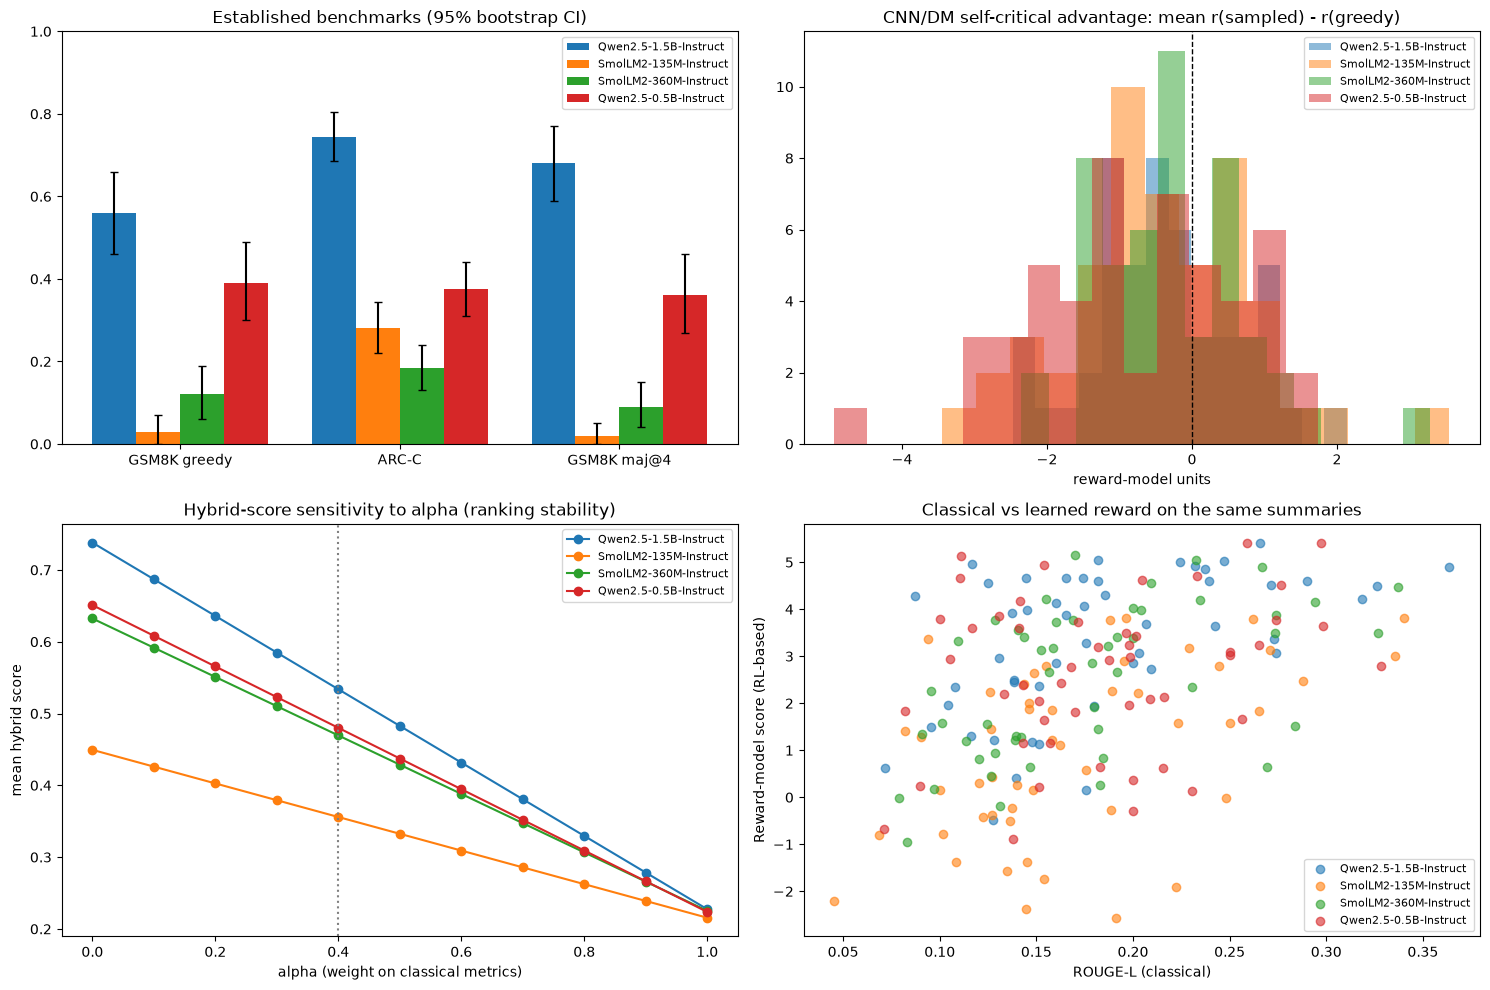


## LLM results

| model | params_M | GSM8K acc (greedy) | GSM8K maj@4 | ARC-C acc | GSM8K J(pi) [MC return] | CNN/DM RM reward (greedy) | SCST advantage (RM units) | ROUGE-L | BERTScore-F1 (rescaled) | Hybrid (a=0.4) |
|---|---|---|---|---|---|---|---|---|---|---|
| Qwen2.5-1.5B-Instruct | 1543.700 | 0.56 [0.46, 0.66] | 0.68 [0.59, 0.77] | 0.74 [0.69, 0.81] | 0.61 [0.53, 0.68] | 3.33 [2.89, 3.73] | -0.35 [-0.62, -0.07] | 0.184 | 0.217 | 0.534 |
| SmolLM2-135M-Instruct | 134.500 | 0.03 [0.00, 0.07] | 0.02 [0.00, 0.05] | 0.28 [0.22, 0.34] | 0.07 [0.05, 0.09] | 1.02 [0.49, 1.52] | -0.46 [-0.81, -0.10] | 0.170 | 0.178 | 0.356 |
| SmolLM2-360M-Instruct | 361.800 | 0.12 [0.06, 0.19] | 0.09 [0.04, 0.15] | 0.18 [0.13, 0.24] | 0.15 [0.12, 0.18] | 2.48 [2.05, 2.89] | -0.26 [-0.52, 0.03] | 0.176 | 0.181 | 0.469 |
| Qwen2.5-0.5B-Instruct | 494.000 | 0.39 [0.30, 0.49] | 0.36 [0.27, 0.46] | 0.38 [0.31, 0.44] | 0.32 [0.25, 0.39] | 2.63 [2.15, 3.07] | -0.76 [-1.16, -0.38] | 0.184 | 0.206 | 0.480 |




In [27]:
# ============================================================================
# 7. Results tables, plots, files
# ============================================================================
rows = []
for n in names:
    g = GEN[n]; gs = GSM[n]; ar = ARC[n]; sm = SUM[n]; rmn = RM[n]
    rows.append({
        "model": n, "params_M": g["params_m"],
        # established benchmarks
        "GSM8K acc (greedy)": ci_str(bootstrap_ci(gs["greedy_correct"]), 2),
        "GSM8K pass@1 (sampled)": ci_str(bootstrap_ci(gs["pass1"]), 2),
        f"GSM8K pass@{K}": ci_str(bootstrap_ci(gs["passk"]), 2),
        f"GSM8K maj@{K}": ci_str(bootstrap_ci(gs["maj"]), 2),
        "ARC-C acc": ci_str(bootstrap_ci(ar["correct"]), 2),
        # RL-based
        "GSM8K J(pi) [MC return]": ci_str(bootstrap_ci(gs["sample_reward"]), 2),
        "ARC-C E[r] (exact)": ci_str(bootstrap_ci(ar["exp_reward"]), 2),
        "CNN/DM RM reward (greedy)": ci_str(bootstrap_ci(rmn["greedy"]), 2),
        "SCST advantage (RM units)": ci_str(bootstrap_ci(rmn["advantage"]), 2),
        "% rollouts beating greedy": round(100 * float((rmn["adv_traj"] > 0).mean()), 1),
        "GSM8K SCST advantage": ci_str(bootstrap_ci(gs["advantage"]), 3),
        # classical summarisation
        "ROUGE-1": round(sm.rouge1.mean(), 3), "ROUGE-2": round(sm.rouge2.mean(), 3), "ROUGE-L": round(sm.rougeL.mean(), 3),
        "BLEU": round(sm.corpus_bleu.iloc[0], 3), "METEOR": round(sm.meteor.mean(), 3),
        "BERTScore-F1 (rescaled)": round(sm.bertscore_f1.mean(), 3), "PPL (own output)": round(float(np.nanmean(sm.ppl)), 2),
        f"Hybrid (a={CFG['alpha']})": round(hybrid_mean(CFG["alpha"], CFG["beta"])[n], 4),
        "gen time (s)": g["gen_seconds"], "peak VRAM (GiB)": g["peak_vram_gib"],
    })
results = pd.DataFrame(rows)
results.to_csv(f"{OUT_DIR}/llm_results.csv", index=False)
sens.to_csv(f"{OUT_DIR}/llm_hybrid_alpha_sensitivity.csv")
pd.DataFrame(META).T.to_csv(f"{OUT_DIR}/llm_reward_meta_evaluation.csv")
pd.concat([SUM[n].assign(model=n, rm_greedy=RM[n]["greedy"], rm_sample_mean=RM[n]["sample_mean"],
                         rm_advantage=RM[n]["advantage"], hybrid=CFG["alpha"] * cls[n] + CFG["beta"] * rm_norm[n])
           for n in names]).to_csv(f"{OUT_DIR}/llm_summarisation_per_sample.csv", index=False)
write_manifest(f"{OUT_DIR}/run_manifest.json", {k: v for k, v in CFG.items()},
               extra=dict(models={n: dict(id=GEN[n]["model_id"], commit=GEN[n]["commit"]) for n in names}))

pd.set_option("display.width", 250, "display.max_columns", 50)
print(results.set_index("model").T.to_string())

fig, ax = plt.subplots(2, 2, figsize=(15, 10))
w = 0.8 / len(names); x = np.arange(3)
for i, n in enumerate(names):
    vals = [bootstrap_ci(GSM[n]["greedy_correct"]), bootstrap_ci(ARC[n]["correct"]), bootstrap_ci(GSM[n]["maj"])]
    m = np.array([v[0] for v in vals]); err = np.array([[v[0] - v[1] for v in vals], [v[2] - v[0] for v in vals]])
    ax[0, 0].bar(x + i * w, m, w, yerr=err, capsize=3, label=n)
ax[0, 0].set_xticks(x + w * (len(names) - 1) / 2); ax[0, 0].set_xticklabels(["GSM8K greedy", "ARC-C", f"GSM8K maj@{K}"])
ax[0, 0].set_ylim(0, 1); ax[0, 0].set_title("Established benchmarks (95% bootstrap CI)"); ax[0, 0].legend(fontsize=8)

for n in names: ax[0, 1].hist(RM[n]["advantage"], bins=15, alpha=0.5, label=n)
ax[0, 1].axvline(0, color="k", ls="--", lw=1)
ax[0, 1].set_title("CNN/DM self-critical advantage: mean r(sampled) - r(greedy)"); ax[0, 1].set_xlabel("reward-model units"); ax[0, 1].legend(fontsize=8)

for n in names: ax[1, 0].plot(sens.index, sens[n], marker="o", label=n)
ax[1, 0].axvline(CFG["alpha"], color="gray", ls=":")
ax[1, 0].set_xlabel("alpha (weight on classical metrics)"); ax[1, 0].set_ylabel("mean hybrid score")
ax[1, 0].set_title("Hybrid-score sensitivity to alpha (ranking stability)"); ax[1, 0].legend(fontsize=8)

for n in names: ax[1, 1].scatter(SUM[n]["rougeL"], RM[n]["greedy"], alpha=0.6, label=n)
ax[1, 1].set_xlabel("ROUGE-L (classical)"); ax[1, 1].set_ylabel("Reward-model score (RL-based)")
ax[1, 1].set_title("Classical vs learned reward on the same summaries"); ax[1, 1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/llm_evaluation_plots.png", dpi=150); plt.show()

# Paste-ready markdown for your write-up
core = results[["model", "params_M", "GSM8K acc (greedy)", f"GSM8K maj@{K}", "ARC-C acc", "GSM8K J(pi) [MC return]",
                "CNN/DM RM reward (greedy)", "SCST advantage (RM units)", "ROUGE-L", "BERTScore-F1 (rescaled)", f"Hybrid (a={CFG['alpha']})"]]
md = "## LLM results\n\n" + df_to_md(core) + "\n"
open(f"{OUT_DIR}/RESULTS_llm.md", "w").write(md); print("\n" + md)
print(f"\nSaved everything in ./{OUT_DIR}/  (results CSV, per-sample CSV, plots, manifest, RESULTS_llm.md)")